    Instructions:
    1. Press Run All (or restart kernel and run all cells).
    2. You will be prompted for an Image ID before the dataset is downloaded.

    
    Task 1: Implement a program which, given an image ID and one of the
    following feature models, visualizes the image and then extracts and
    prints (in a human readable form) the corresponding feature descriptors:

    1. Color moments (CM10x10)
    2. Histograms of oriented gradients (HOG)
    3. ResNet-AvgPool-1024
    4. ResNet-Layer3-1024
    5. ResNet-FC-1000

In [1]:
IMG_ID = int(input("Provide an Image ID in the Caltech101 dataset in range [0, 8676]."))

In [2]:
# Print full tensors

import torch

torch.set_printoptions(threshold=10_000)

# Initialize dataset, downloads into <git_root>/Code/caltech101 if not present. Untracked by git.

import os
from torchvision.datasets import Caltech101

dataset = Caltech101(root=os.path.abspath(""), download=True)

print(dataset)

# __getitem__ returns a tuple (PIL, category number).

Files already downloaded and verified
Dataset Caltech101
    Number of datapoints: 8677
    Root location: /Users/gokulvsd/repos/ViVeC/Code/caltech101
    Target type: ['category']


Image ID:  2500


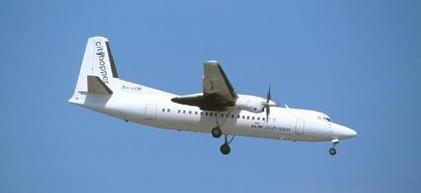

Category: airplanes


In [3]:
# Visualize an image given an image ID.

image, category = dataset[IMG_ID][0], dataset.categories[dataset[IMG_ID][1]]

if image.mode != 'RGB':
    print("WARNING: The provided image does not have RGB channels, the image will be converted to RGB.")
    image = image.convert('RGB')


print("Image ID: ", IMG_ID)
display(image)
print("Category:", category)

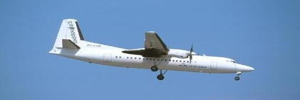

In [4]:
# Resize image to 300 x 100.

image300x100 = image.resize((300, 100))

display(image300x100)

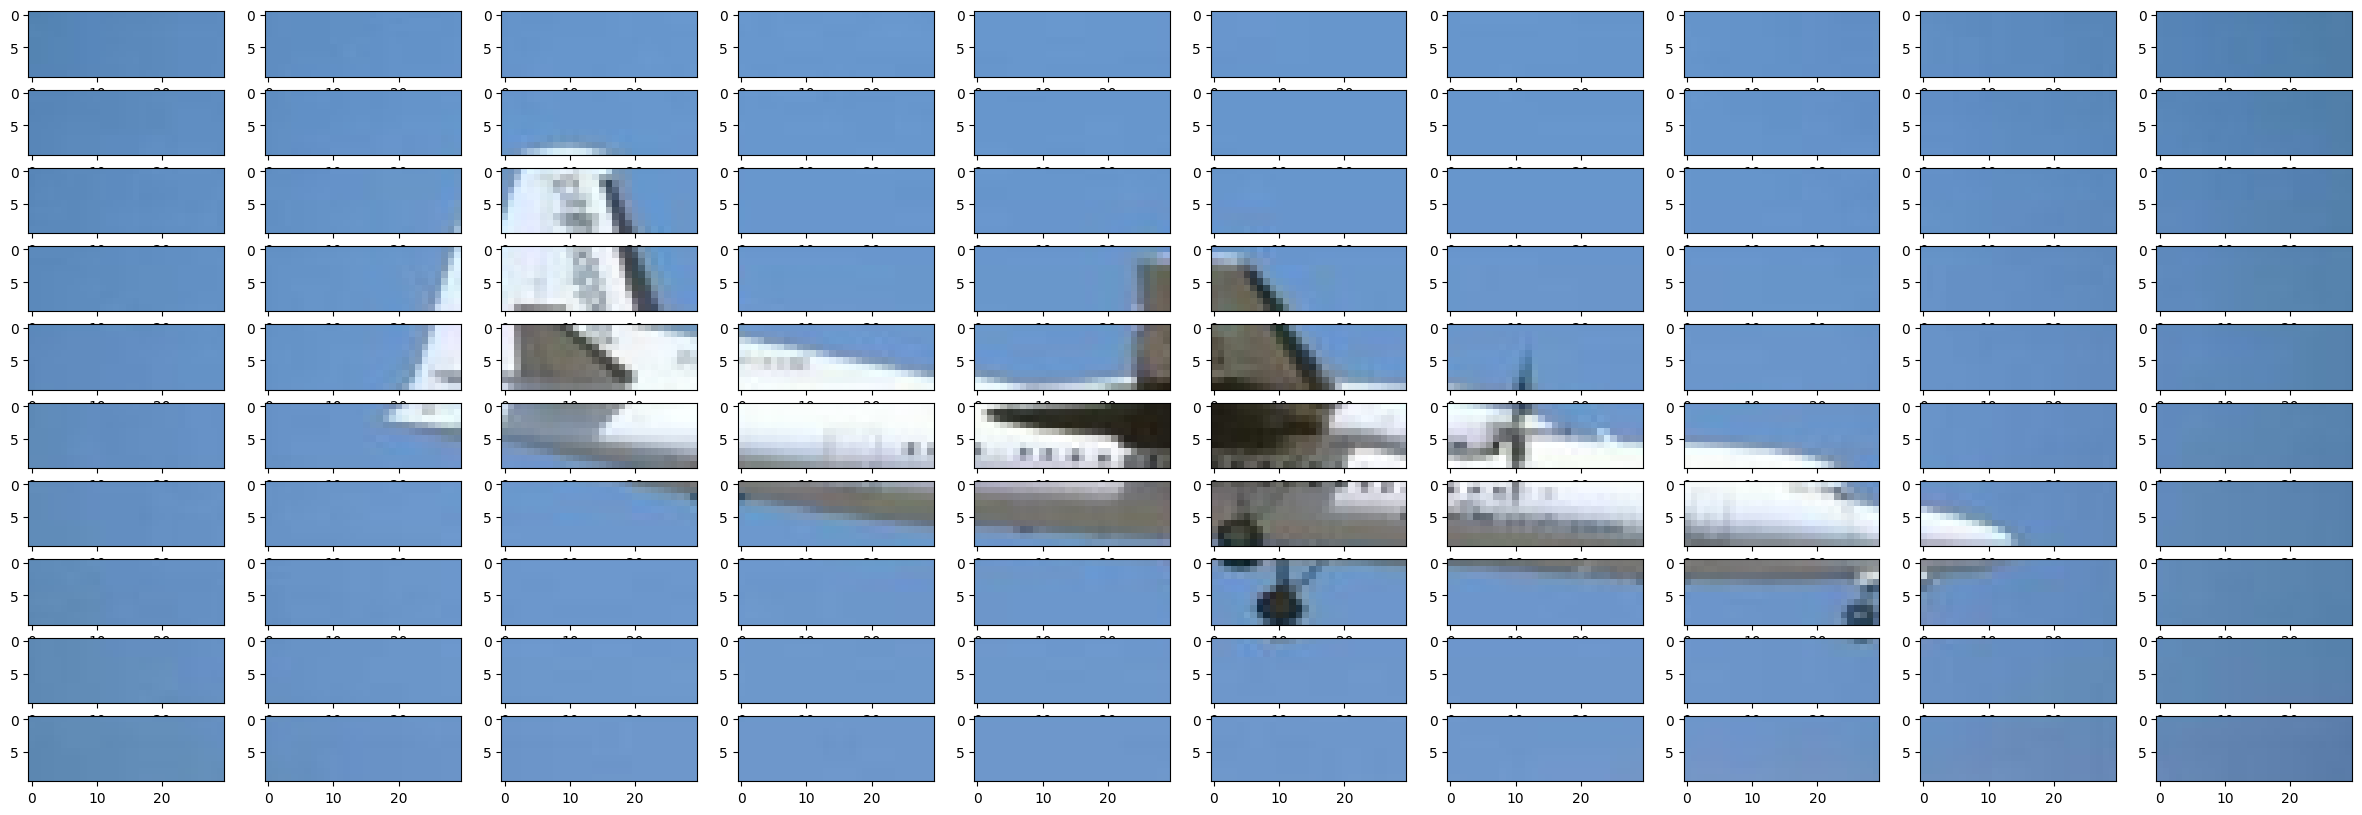

In [5]:
# Partition image into a 10x10 grid (each cell is 30x10).

from torchvision.transforms import transforms

import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=10, ncols=10, figsize=(30,10))

from utils.utilities import partition_to_grid

grid = partition_to_grid(image300x100, num_rows=10, num_cols=10, hor_pixels=30, ver_pixels=10)

print

for i in range(10):
    for j in range(10):
        axes[i, j].imshow(transforms.ToPILImage()(grid[i][j]).convert('RGB'))

Length of color vector:  900


tensor([ 8.9893e+01,  3.4893e+00, -2.4003e+00,  1.3639e+02,  2.8749e+00,
        -1.4487e+00,  1.8664e+02,  4.2069e+00, -3.1940e+00,  9.7680e+01,
         1.9709e+00, -4.9096e-01,  1.4451e+02,  2.1063e+00, -1.3728e+00,
         1.9761e+02,  2.9434e+00, -1.8109e+00,  1.0281e+02,  1.2223e+00,
        -8.5799e-01,  1.4972e+02,  1.2395e+00, -9.1042e-01,  2.0376e+02,
         1.2196e+00, -8.8255e-01,  1.0420e+02,  9.0554e-01, -4.3087e-01,
         1.5120e+02,  9.0554e-01, -4.3087e-01,  2.0520e+02,  9.0554e-01,
        -4.3087e-01,  1.0385e+02,  6.9028e-01, -5.0728e-01,  1.5073e+02,
         7.2725e-01, -6.4199e-01,  2.0479e+02,  6.6630e-01, -5.4580e-01,
         1.0361e+02,  9.0765e-01,  1.0088e+00,  1.5009e+02,  5.9270e-01,
        -4.4114e-01,  2.0436e+02,  6.4581e-01,  6.9994e-01,  1.0263e+02,
         7.4428e-01, -4.6549e-01,  1.4963e+02,  7.4428e-01, -4.6549e-01,
         2.0363e+02,  7.4428e-01, -4.6549e-01,  9.9267e+01,  1.5151e+00,
        -7.0390e-01,  1.4549e+02,  2.2007e+00, -1.2

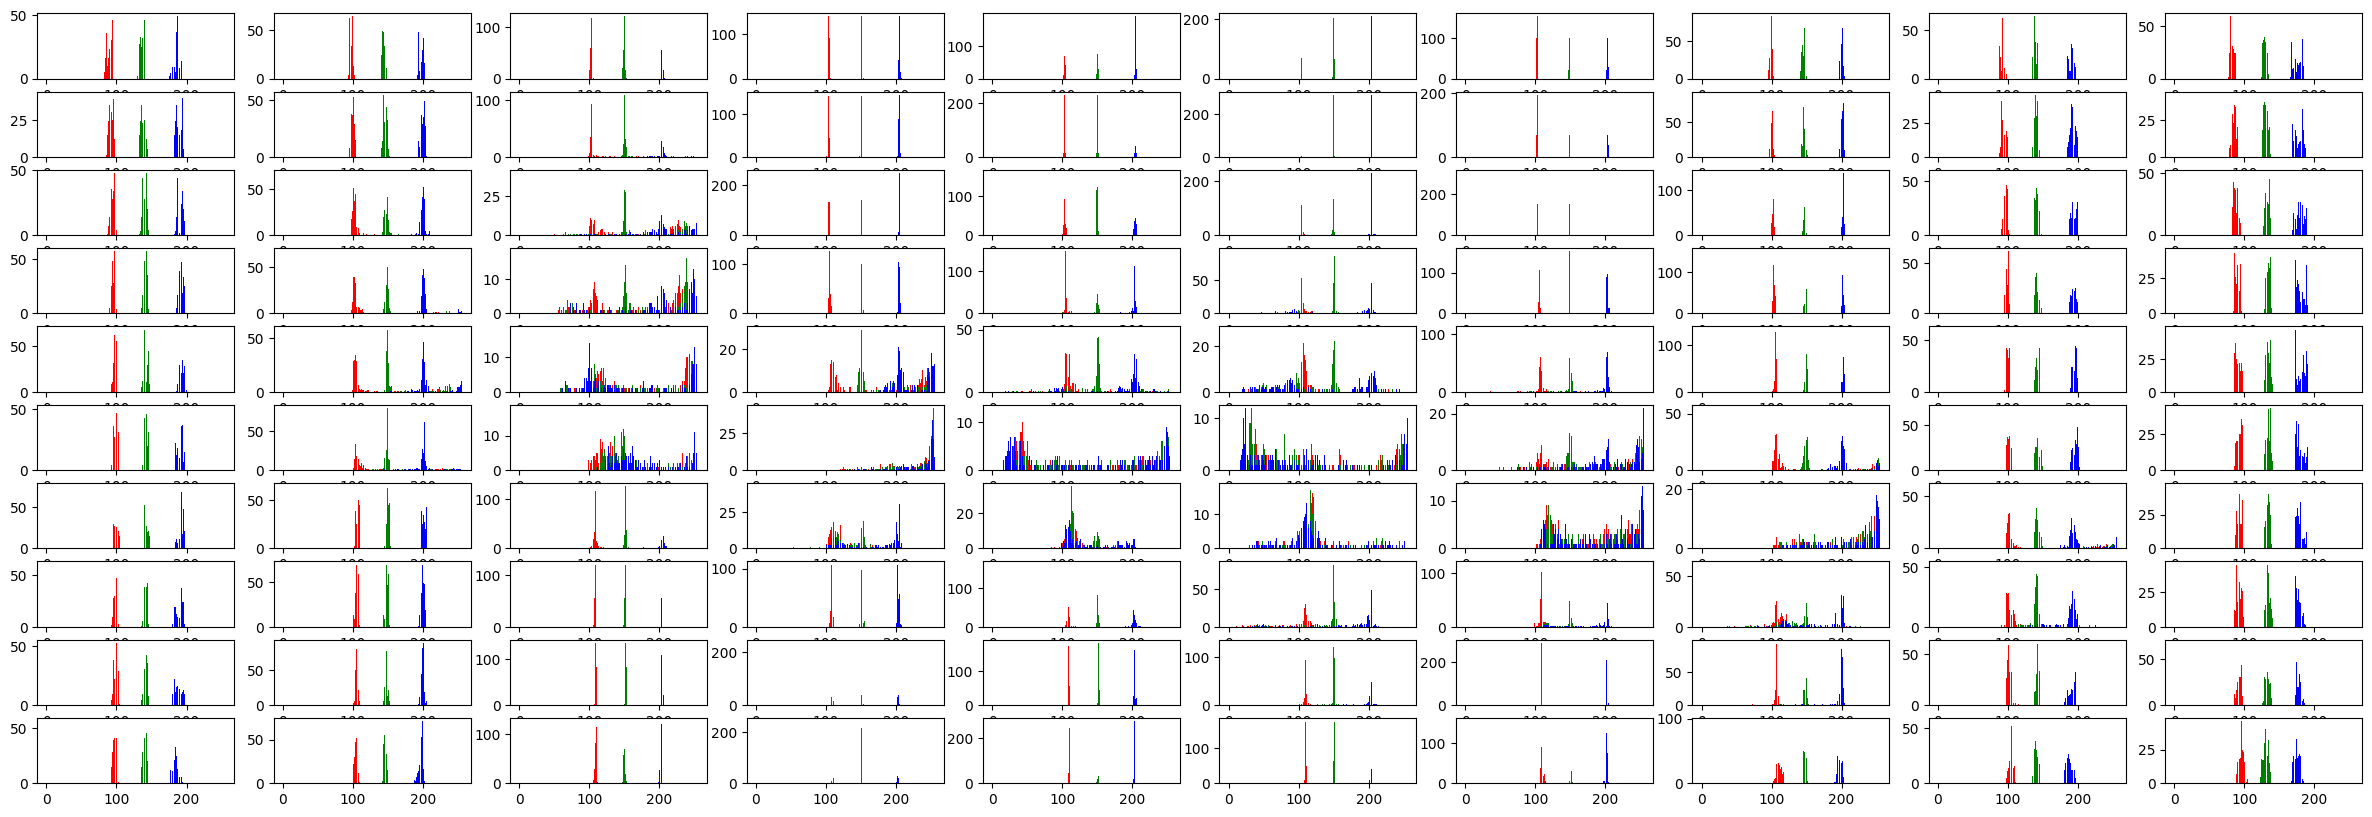

In [6]:
# Color moments (CM10x10).

# Color moments capture the distribution of intensities of each channel (R, G, B).
# In essense, we will be calculating the mean, standard deviation, and skewness of
# each 10x30 (HxW) grid cell of which there are 10x10, for each channel, of which there are 3.
# This results in a feature descriptor of length 10x10x3x3 = 900.

# Each cell tensor's shape is 3 x 10 x 30 (C x H x W)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=10, ncols=10, figsize=(30,10))

# Displaying histograms:
for i in range(len(grid)):
    for j in range(len(grid[0])):

        cell = grid[i][j]


        hist_red = torch.histc(cell[0].float(), bins=256, min=0, max=255)
        hist_green = torch.histc(cell[1].float(), bins=256, min=0, max=255)
        hist_blue = torch.histc(cell[2].float(), bins=256, min=0, max=255)

        axes[i, j].bar(range(256), hist_red, color='red')
        axes[i, j].bar(range(256), hist_green, color='green')
        axes[i, j].bar(range(256), hist_blue, color='blue')

# Represented as a 900-dim torch vector.
# The sequential vector representation is as follows:
#
# Row-major order of cells (10x10 cells), with each cell having 3 channel (RGB in that order),
# with each channel having 3 values (mean, standard deviation, skewness in that order).
#
# vec: [<cell_1 <red <mean, stdev, skew>>, <green <...>>, <blue <...>>>, <cell_2 ...>...]

from feature_extractors.color_moments import get_color_vector

color_vector = get_color_vector(grid)

print("Length of color vector: ", len(color_vector))
display(color_vector)

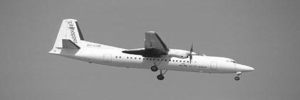

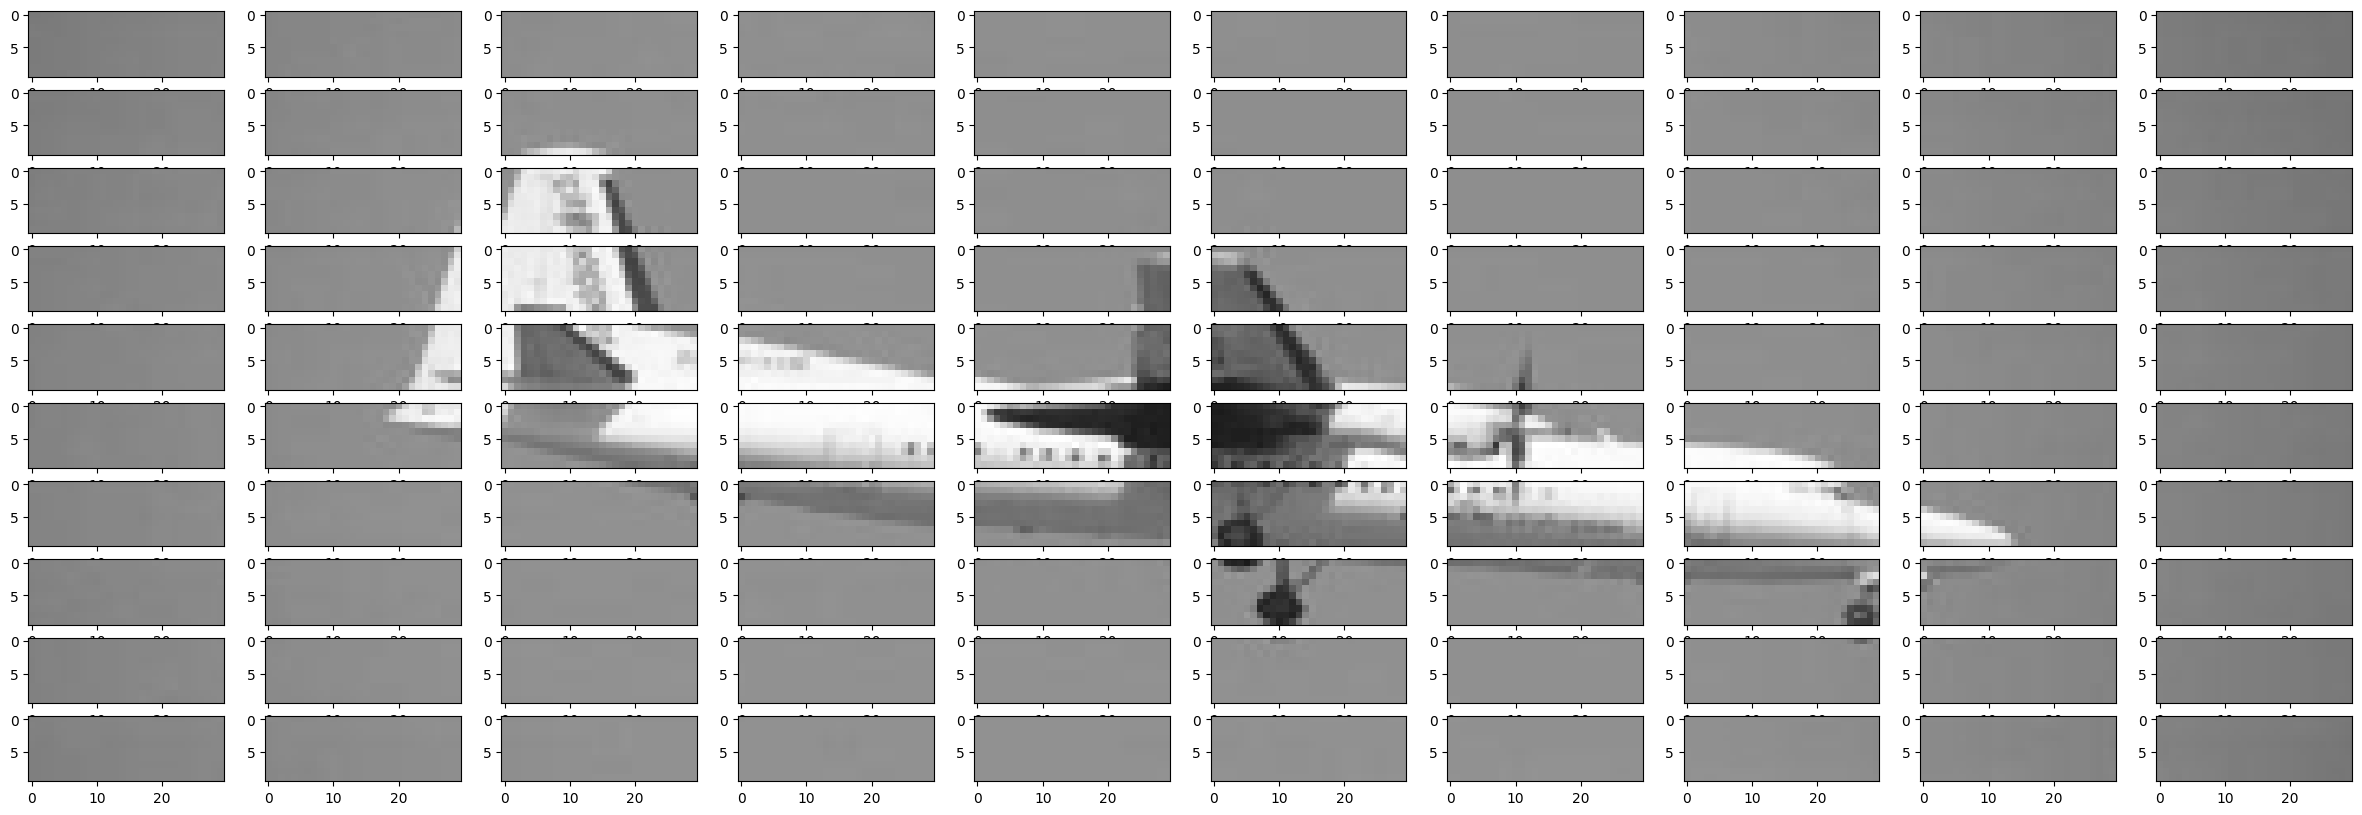

In [7]:
# Histograms of oriented gradients (HOG).

# Convert to grayscale.

from torchvision.transforms import Grayscale

gs_image = Grayscale()(image300x100)

display(gs_image)

# Convert to grid using previously defined function.

gs_grid = partition_to_grid(gs_image, num_rows=10, num_cols=10, hor_pixels=30, ver_pixels=10)

fig, axes = plt.subplots(nrows=10, ncols=10, figsize=(30,10))

for i in range(10):
    for j in range(10):
        axes[i, j].imshow(transforms.ToPILImage()(gs_grid[i][j]).convert('RGB'))

Length of HOG vector:  900


tensor([7.2585e+02, 2.0744e+02, 2.7718e+03, 9.9475e+02, 6.0516e+02, 6.0070e+02,
        9.9443e+02, 2.7563e+03, 1.7376e+02, 2.7223e+02, 2.0180e+02, 2.9540e+03,
        1.0878e+03, 6.4431e+02, 6.3830e+02, 1.0695e+03, 2.9395e+03, 1.8513e+02,
        2.8415e+02, 2.1139e+02, 3.0475e+03, 1.1246e+03, 6.5956e+02, 6.5875e+02,
        1.1255e+03, 3.0367e+03, 1.9075e+02, 7.1069e+02, 1.9876e+02, 3.0681e+03,
        1.1596e+03, 6.6607e+02, 6.6516e+02, 1.1604e+03, 3.0823e+03, 1.9387e+02,
        4.2129e+02, 1.8086e+02, 3.0489e+03, 1.1341e+03, 6.4798e+02, 6.5717e+02,
        1.1450e+03, 3.0630e+03, 1.8434e+02, 4.2129e+02, 1.7839e+02, 3.0217e+03,
        1.1281e+03, 6.5331e+02, 6.5437e+02, 1.1334e+03, 3.0343e+03, 1.8310e+02,
        0.0000e+00, 1.7695e+02, 3.0250e+03, 1.1363e+03, 6.5058e+02, 6.4404e+02,
        1.1353e+03, 3.0352e+03, 1.7695e+02, 4.1704e+02, 1.8490e+02, 2.9213e+03,
        1.1307e+03, 6.6651e+02, 6.5022e+02, 1.1207e+03, 2.9199e+03, 1.7839e+02,
        6.6619e+02, 1.7891e+02, 2.7546e+

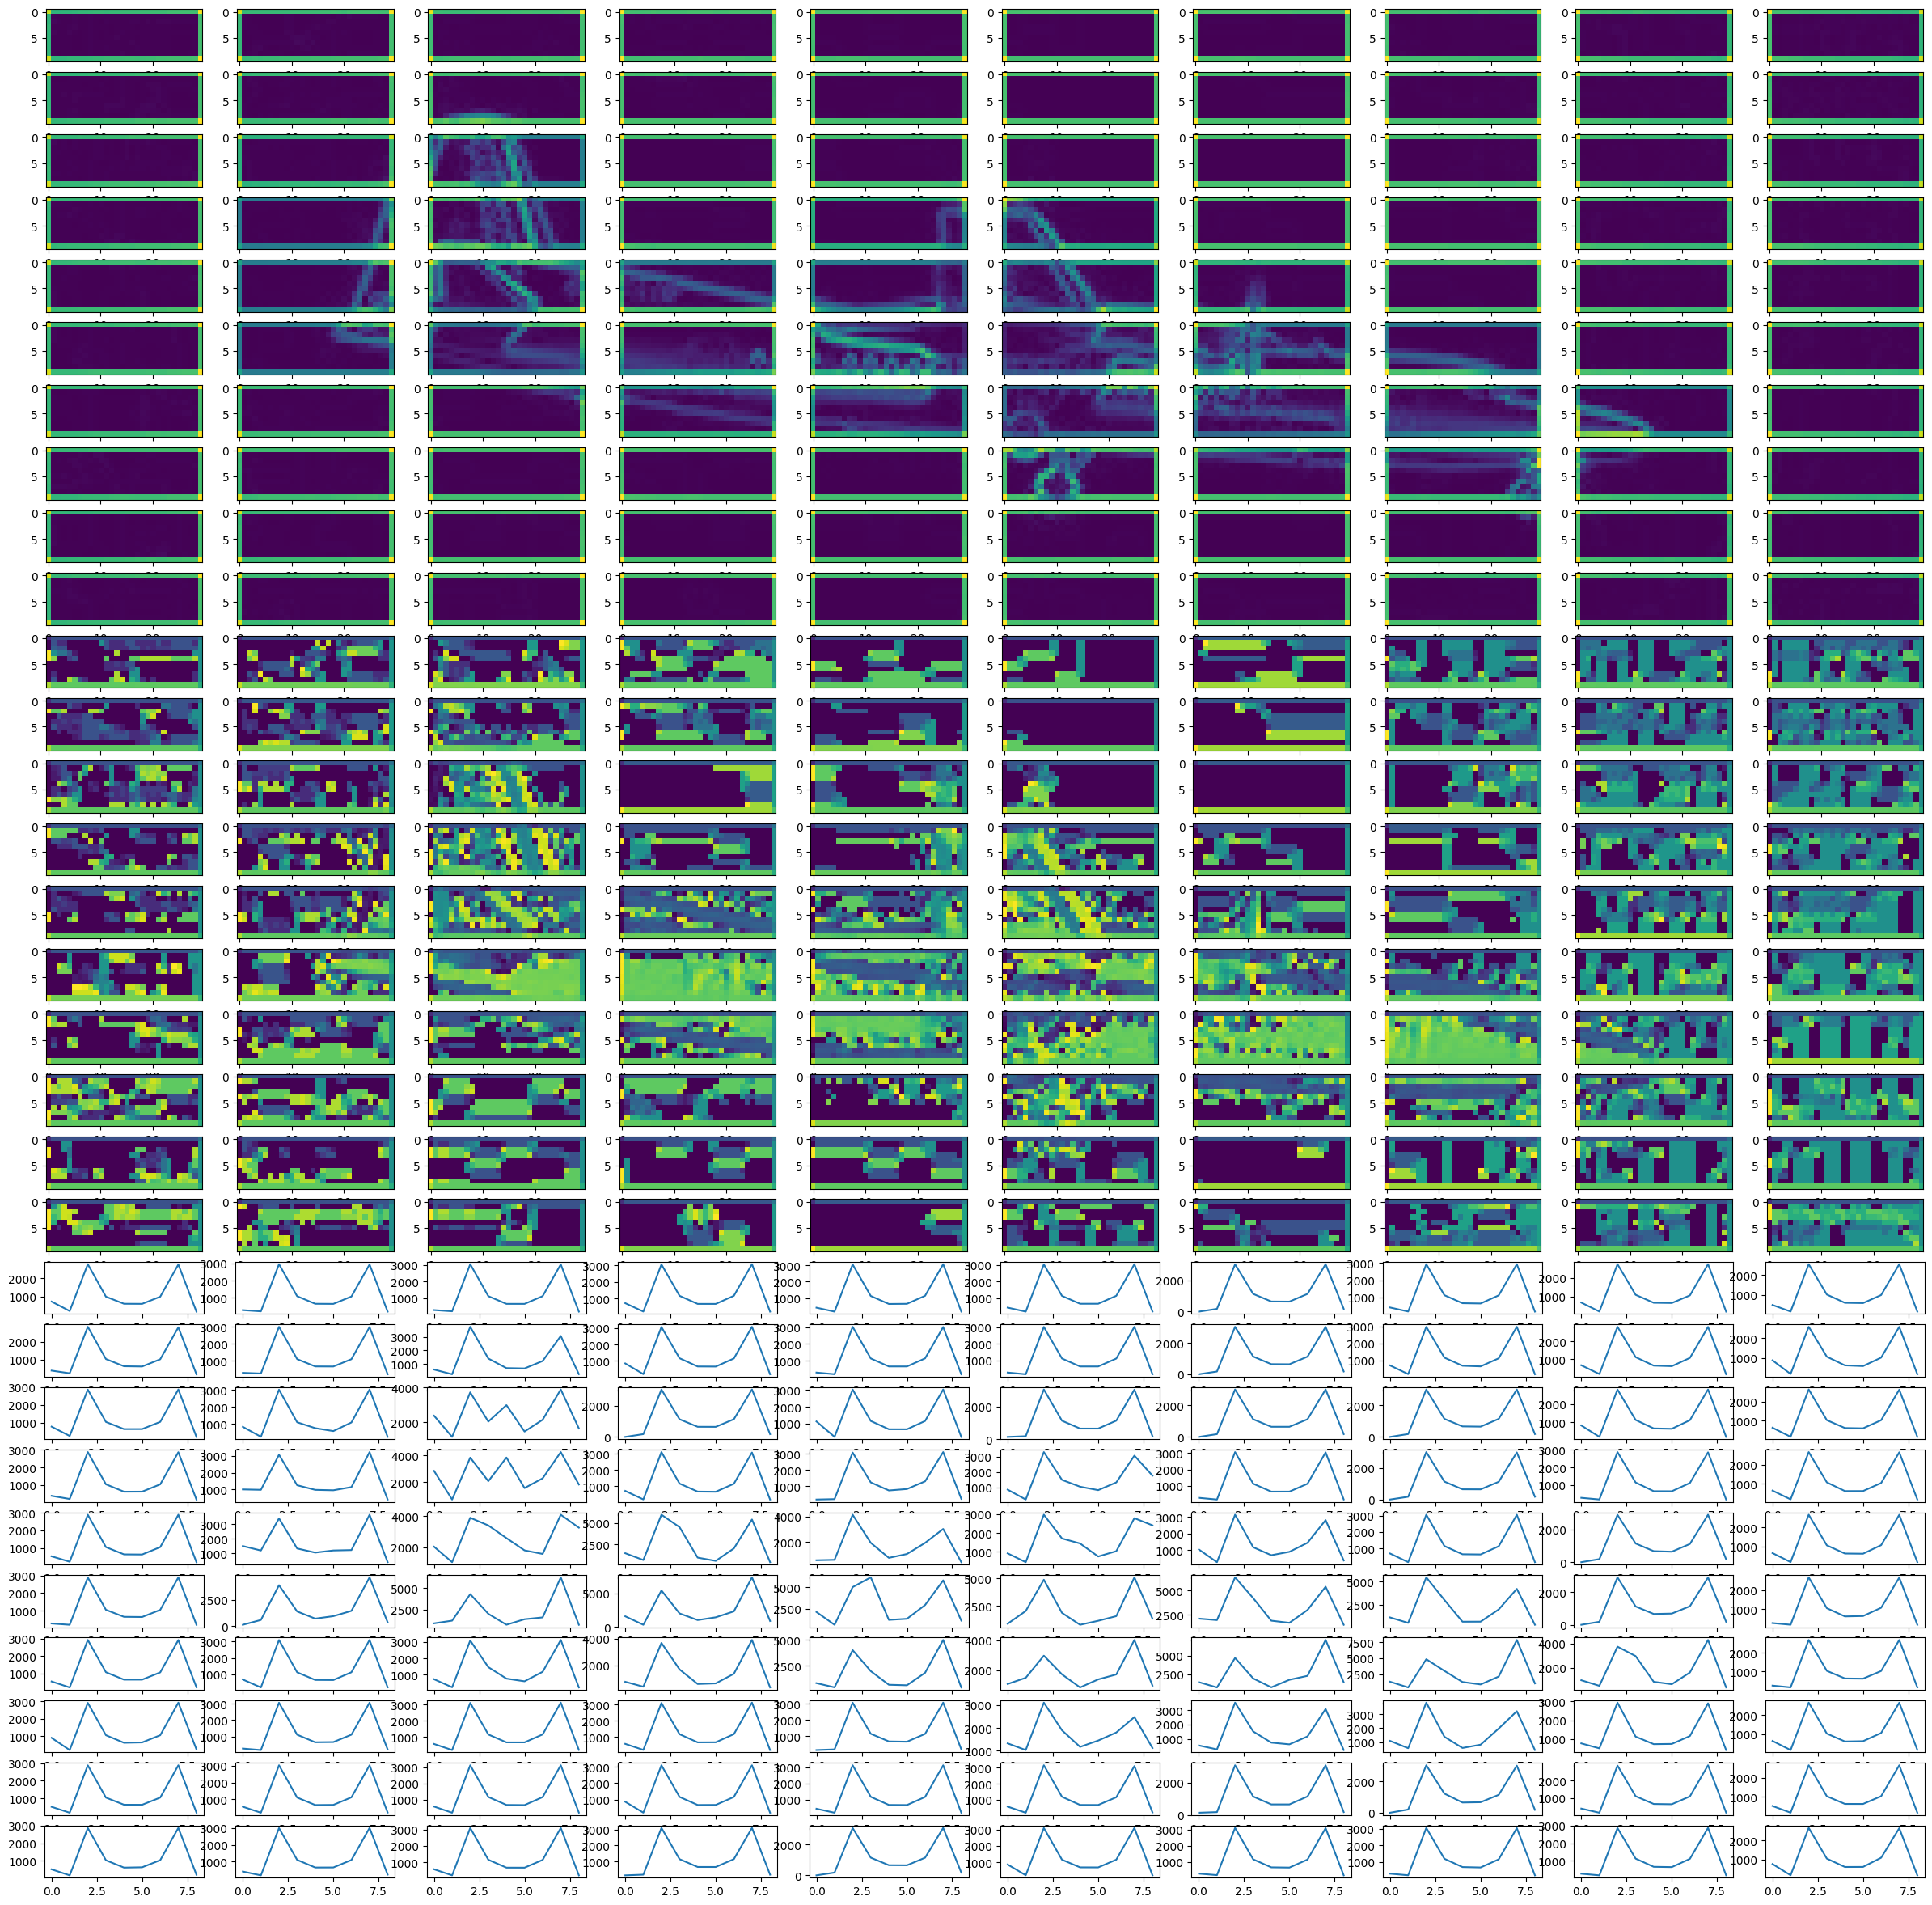

In [8]:
# 9 bin (signed) magnitude-weighted gradient histograms.
# Signed implies we consider 360 degrees, hence 9 bins => 40 degree bins.

from feature_extractors.HOG import get_hog_vector_from_bins, get_gradient_bins, get_gradients

g_mags, g_dirs = get_gradients(gs_grid)

gradient_bins = get_gradient_bins(g_mags, g_dirs)

hog_vector = get_hog_vector_from_bins(gradient_bins)


# Visualize gradient magnitude, dimentions and histograms.

fig, axes = plt.subplots(nrows=30, ncols=10, figsize=(30,30))

for i in range(len(g_mags)):
    for j in range(len(g_mags[0])):

        # Display magnitudes (on top third)
        axes[i, j].imshow(g_mags[i][j])
        # Display directions (middle third)
        axes[10 + i, j].imshow(g_dirs[i][j])
        # Display histogram of oriented gradients (on bottom third)
        axes[20 + i, j].plot(gradient_bins[i][j])

# Represent as a 900-dim torch vector.
# The sequential vector representation is as follows:
#
# Row-major order of cells (10x10 cells), with each cell having 9 values, one each
# for binned degrees: 0, 40, 80, 120, 160, 200, 240, 280, 320. 
# 0 is the same as 360.
# The magnitude of the gradient is distributed according to its direction,
# with the adjacent bins getting the magnitude weighted according to how
# close the direction is to the bin.
#
# vec: [<cell_1 <0, 40, 80, 120 ... 320>>, <cell_2 ...>...]

print("Length of HOG vector: ", len(hog_vector))
display(hog_vector)

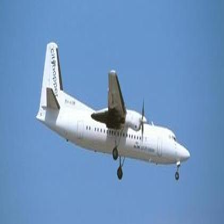

In [9]:
# Resize original image to 224x224 and convert to float tensor.

image224x224 = image.resize((224, 224))

display(image224x224)

img_tensor = transforms.Compose([transforms.ToTensor()])(image224x224)

In [10]:
# ResNet-50 Pretrained with default weights.

from feature_extractors.resnet_50 import get_resnet50_feature_vectors

avgpool_vector, layer3_vector, fc1000_vector = get_resnet50_feature_vectors(img_tensor)

print("\nLength of ResNet-AvgPool-1024 vector: ", len(avgpool_vector))
display(avgpool_vector)


Length of ResNet-AvgPool-1024 vector:  1024


tensor([0.0000e+00, 0.0000e+00, 2.4474e-02, 0.0000e+00, 0.0000e+00, 8.1295e-05,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.3474e-02, 9.4835e-03, 1.0527e-02,
        0.0000e+00, 2.4621e-02, 1.6805e-02, 4.5955e-02, 0.0000e+00, 0.0000e+00,
        6.7363e-03, 6.4117e-02, 1.7164e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        3.2208e-02, 0.0000e+00, 2.6127e-02, 4.7727e-03, 7.1387e-02, 6.0975e-03,
        1.1474e-01, 6.5389e-03, 0.0000e+00, 1.2540e-01, 4.9255e-02, 6.9698e-02,
        1.4605e-01, 5.3389e-03, 0.0000e+00, 4.7850e-02, 2.1027e-02, 1.3541e-02,
        0.0000e+00, 4.5692e-02, 5.4834e-04, 2.5232e-02, 7.2394e-03, 6.7090e-03,
        0.0000e+00, 8.0805e-03, 0.0000e+00, 2.0228e-02, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 7.2295e-02, 0.0000e+00, 3.2361e-01, 8.0544e-04,
        3.9365e-04, 0.0000e+00, 4.1046e-02, 0.0000e+00, 9.7567e-03, 0.0000e+00,
        6.3325e-02, 1.7201e-02, 0.0000e+00, 0.0000e+00, 3.0121e-02, 0.0000e+00,
        1.2670e-02, 9.1676e-03, 4.5822e-

In [11]:
print("\nLength of ResNet-Layer3-1024 vector: ", len(layer3_vector))
display(layer3_vector)


Length of ResNet-Layer3-1024 vector:  1024


tensor([4.3171e-01, 5.9370e-01, 2.0711e-02, 3.0501e-01, 6.5332e-02, 1.5223e-01,
        3.4620e-01, 1.0407e-01, 4.8697e-02, 1.1381e-02, 6.0787e-01, 3.3123e-02,
        1.0132e+00, 3.3491e-02, 1.0550e-01, 1.0744e+00, 2.8746e-01, 5.1147e-01,
        1.3987e+00, 4.8856e-01, 8.6755e-01, 1.7208e+00, 1.1046e-01, 9.1160e-01,
        1.8812e-01, 4.4708e-01, 7.3544e-01, 1.1625e-01, 5.7632e-01, 6.2480e-02,
        7.5621e-02, 6.6495e-02, 9.9607e-01, 2.0958e-01, 5.9892e-02, 1.0185e+00,
        1.9214e-01, 8.8284e-01, 2.4141e+00, 3.5669e-01, 1.1483e-01, 1.9947e-01,
        1.1642e-01, 3.6030e-01, 1.6917e-01, 2.1921e-01, 1.6150e-01, 1.9384e-01,
        3.2674e-01, 3.6699e-01, 1.4940e+00, 2.6633e+00, 1.3645e-01, 3.4594e-01,
        2.9213e-01, 8.3658e-01, 1.9854e-01, 1.0417e+00, 7.2052e-02, 2.5815e-01,
        4.1654e-01, 8.2115e-02, 1.0352e-01, 2.3437e-01, 2.1861e-01, 2.8504e-01,
        3.8328e-01, 8.7267e-03, 6.2489e-01, 1.3144e-01, 6.4763e-02, 1.3837e-01,
        2.6357e-02, 9.8134e-01, 4.8248e-

In [12]:
print("\nLength of ResNet-FC-1000 vector: ", len(fc1000_vector))
display(fc1000_vector)


Length of ResNet-FC-1000 vector:  1000


tensor([ 3.0445e-01, -3.2170e-02,  7.2025e-02,  1.7276e-01,  2.2728e-01,
         3.1033e-01, -5.1111e-01, -3.1061e-01, -5.9202e-02, -1.5632e-01,
         3.8396e-01,  1.1891e-01,  2.6641e-02, -4.6989e-01, -1.3329e-02,
        -1.8563e-01,  8.1828e-02, -3.7870e-01, -2.9724e-01, -1.3542e-01,
         1.4208e-01,  6.8695e-01, -3.5940e-01, -2.2319e-01, -3.0485e-01,
        -3.8424e-02,  3.7467e-01,  4.1525e-02,  3.0629e-02,  5.6457e-01,
        -2.0733e-01, -1.1639e-01,  1.9104e-01,  7.6228e-02, -3.0424e-01,
         6.4692e-02,  7.4114e-02, -3.0583e-01,  4.1575e-01,  4.4003e-01,
        -6.8256e-02,  2.7328e-01,  9.0324e-02,  3.5334e-01,  2.8038e-01,
         5.0378e-02,  6.1542e-02,  5.4023e-01,  4.1411e-01, -1.3036e-01,
        -2.3066e-01,  3.2968e-01,  4.0830e-02, -2.2267e-01, -1.3584e-01,
        -4.1147e-02, -4.1365e-01, -2.0420e-01, -2.3475e-01,  2.4295e-01,
        -4.4308e-02, -1.3610e-01,  4.6244e-03, -7.9822e-02,  4.5290e-01,
         1.9650e-01,  4.4285e-01, -4.9405e-01,  2.7